# BBBP 예측 미니 프로젝트 — Day 4: 모델 검증과 오류 분석

오늘은 **새 모델을 만들거나 성능을 높이는 날이 아닙니다.** Day 3의 데이터 분할, 특징, 모델 설정을 그대로 재현한 뒤 다음 두 질문을 확인합니다.

1. 훈련 데이터 안에서 5-fold 교차검증을 했을 때도 모델 성능이 비슷하게 나타나는가?
2. 고정된 test set에서 Random Forest는 어떤 분자를 잘못 분류했는가?

중요한 원칙은 다음과 같습니다.

- `BBB+ = 1`, `BBB- = 0`으로 해석합니다.
- Day 3에서 분리한 test set은 교차검증과 모델 선택에 사용하지 않습니다.
- Logistic Regression의 표준화는 각 fold의 훈련 부분에만 맞춥니다.
- Day 3의 세 모델, 특징, 하이퍼파라미터와 0.5 결정 기준을 바꾸지 않습니다.
- 관찰된 차이는 기록하되 원인이나 인과관계로 단정하지 않습니다.

## 1. 실행 환경 준비

**입력:** 현재 Python 환경과 프로젝트 폴더입니다.  
**계산:** 분석에 필요한 라이브러리를 불러오고 결과 저장 폴더를 정합니다.  
**출력:** 실제 실행에 사용한 버전과 경로를 표로 보여줍니다.  
**왜 필요한가:** 같은 코드를 새 환경에서 다시 실행하려면 어떤 도구와 버전을 썼는지 알아야 하기 때문입니다.

In [1]:
from pathlib import Path
import hashlib
import io
import logging
import os
import re
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
WORK_DIR = PROJECT_ROOT / "work"
RESULTS_DIR.mkdir(exist_ok=True)
WORK_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(WORK_DIR / "matplotlib-cache"))

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit
import seaborn as sns
import sklearn
from IPython.display import Markdown, display
from rdkit import Chem, DataStructs, rdBase
from rdkit.Chem import Crippen, Descriptors, Draw, Lipinski, rdFingerprintGenerator, rdMolDescriptors
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)

versions = pd.Series(
    {
        "Python": sys.version.split()[0],
        "NumPy": np.__version__,
        "pandas": pd.__version__,
        "RDKit": rdkit.__version__,
        "scikit-learn": sklearn.__version__,
        "Matplotlib": matplotlib.__version__,
        "seaborn": sns.__version__,
    },
    name="version",
)
display(versions.to_frame())
print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"결과 폴더: {RESULTS_DIR}")

,version
Python,3.12.13
NumPy,2.5.2
pandas,3.0.5
RDKit,2026.03.5
scikit-learn,1.9.0
Matplotlib,3.11.1
seaborn,0.13.2


프로젝트 루트: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp
결과 폴더: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results


## 2. Day 3의 모델용 데이터 재현

**입력:** Day 1~3과 같은 DeepChem 공개 BBBP URL의 원본 2,050행입니다.  
**계산:** Day 3과 똑같이 RDKit 파싱 실패 11행을 학습 대상에서 제외하고, canonical SMILES 라벨 충돌 20행과 동일 라벨 중복 54행을 처리합니다.  
**출력:** 최종 모델용 데이터 1,965행과 정제 수량 검증 결과입니다.  
**왜 필요한가:** Day 4가 다른 데이터를 우연히 사용하면 Day 3 결과와 공정하게 비교할 수 없기 때문입니다. 원본 CSV는 저장소에 복사하지 않습니다.

In [2]:
DATA_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"
original_df = pd.read_csv(DATA_URL)
original_df["source_index"] = original_df.index

rdBase.LogToPythonLogger()
rdkit_logger = logging.getLogger("rdkit")
rdkit_logger.setLevel(logging.ERROR)
original_log_handlers = rdkit_logger.handlers[:]
for existing_handler in original_log_handlers:
    rdkit_logger.removeHandler(existing_handler)

def parse_smiles_with_reason(smiles):
    'SMILES를 RDKit Mol로 변환하고 실패 이유를 함께 반환합니다.'
    if pd.isna(smiles):
        return None, "SMILES 값이 비어 있습니다."
    log_stream = io.StringIO()
    log_handler = logging.StreamHandler(log_stream)
    log_handler.setLevel(logging.ERROR)
    rdkit_logger.addHandler(log_handler)
    try:
        mol = Chem.MolFromSmiles(str(smiles))
    except Exception as exc:
        mol = None
        log_stream.write(f"{type(exc).__name__}: {exc}")
    finally:
        rdkit_logger.removeHandler(log_handler)
    messages = []
    for line in log_stream.getvalue().splitlines():
        cleaned = re.sub(r"^\[\d{2}:\d{2}:\d{2}\]\s*", "", line.strip())
        if cleaned:
            messages.append(cleaned)
    error_message = " | ".join(messages)
    if mol is None and not error_message:
        error_message = "RDKit이 분자 객체를 반환하지 않았습니다."
    return mol, error_message

parse_results = original_df["smiles"].map(parse_smiles_with_reason)
audit_df = original_df.copy()
audit_df["mol"] = parse_results.map(lambda result: result[0])
audit_df["parse_error"] = parse_results.map(lambda result: result[1])
audit_df["parse_ok"] = audit_df["mol"].notna()
for original_handler in original_log_handlers:
    rdkit_logger.addHandler(original_handler)

candidate_df = audit_df.loc[audit_df["parse_ok"]].copy()
candidate_df["canonical_smiles"] = candidate_df["mol"].map(
    lambda mol: Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
)
group_label_counts = candidate_df.groupby("canonical_smiles")["p_np"].nunique()
conflicting_keys = set(group_label_counts.loc[group_label_counts > 1].index)
without_conflicts_df = candidate_df.loc[
    ~candidate_df["canonical_smiles"].isin(conflicting_keys)
].copy()
final_model_df = (
    without_conflicts_df.sort_values("source_index")
    .drop_duplicates(subset="canonical_smiles", keep="first")
    .reset_index(drop=True)
)

original_count = len(original_df)
parse_failure_count = int((~audit_df["parse_ok"]).sum())
conflicting_rows_excluded = int(candidate_df["canonical_smiles"].isin(conflicting_keys).sum())
same_label_duplicate_excluded = len(candidate_df) - conflicting_rows_excluded - len(final_model_df)

assert original_count == 2050
assert parse_failure_count == 11
assert conflicting_rows_excluded == 20
assert same_label_duplicate_excluded == 54
assert len(final_model_df) == 1965
assert final_model_df["canonical_smiles"].is_unique
assert original_count == (
    parse_failure_count
    + same_label_duplicate_excluded
    + conflicting_rows_excluded
    + len(final_model_df)
)

cleaning_check = pd.DataFrame(
    {
        "항목": ["원본", "파싱 실패", "동일 라벨 중복 제외", "라벨 충돌 제외", "최종 모델용"],
        "행 수": [2050, 11, 54, 20, len(final_model_df)],
    }
)
display(cleaning_check)

,항목,행 수
0,원본,2050
1,파싱 실패,11
2,동일 라벨 중복 제외,54
3,라벨 충돌 제외,20
4,최종 모델용,1965


## 3. Day 3 train/test 분할이 같은지 확인

**입력:** 위에서 재현한 최종 1,965행과 Day 3의 `test_size=0.20`, `stratify=p_np`, `random_state=42` 설정입니다.  
**계산:** 다시 분할한 뒤 행 순서, canonical SMILES 순서와 집합을 SHA-256 해시로 요약해 Day 3 기준값과 비교합니다.  
**출력:** train/test 행 수, 클래스 수, 해시 일치 여부입니다.  
**왜 필요한가:** 행 수만 같아도 실제 분자가 다를 수 있으므로, 분자 집합까지 같다는 것을 확인하기 위해서입니다.

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

train_df, test_df = train_test_split(
    final_model_df,
    test_size=TEST_SIZE,
    stratify=final_model_df["p_np"],
    random_state=RANDOM_STATE,
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
y_train = train_df["p_np"].to_numpy()
y_test = test_df["p_np"].to_numpy()

def stable_hash(values):
    joined = "\n".join(map(str, values))
    return hashlib.sha256(joined.encode("utf-8")).hexdigest()

reproduced_hashes = {
    "train_source_order": stable_hash(train_df["source_index"]),
    "test_source_order": stable_hash(test_df["source_index"]),
    "train_canonical_order": stable_hash(train_df["canonical_smiles"]),
    "test_canonical_order": stable_hash(test_df["canonical_smiles"]),
    "train_canonical_set": stable_hash(sorted(train_df["canonical_smiles"])),
    "test_canonical_set": stable_hash(sorted(test_df["canonical_smiles"])),
}
expected_day3_hashes = {
    "train_source_order": "7a21d868677d85e44b64087819ec59c7a4979545193463ae36bcd97a11c5a38a",
    "test_source_order": "a2cafded08e638f85b2ae931d49de5f054bf12e7f640cbac7c9e980ffe6fe699",
    "train_canonical_order": "c249feb2bf9d4990e27abf9d729c40daa2a2ddb1a909425533998ab4e250e12f",
    "test_canonical_order": "50a2615aed771bc9069919b5a787bdcf517834534b1cb91b605651595f5f5808",
    "train_canonical_set": "742e6421a9b1c7a6a46aa9d2583349123d8f452692d22af5e391ae7ec70de662",
    "test_canonical_set": "1a40a2d43946514d4cf0233c3decbea5d3209f941181264dc7dc8ed8e6786f3c",
}

assert len(train_df) == 1572 and len(test_df) == 393
assert train_df["p_np"].value_counts().sort_index().to_dict() == {0: 372, 1: 1200}
assert test_df["p_np"].value_counts().sort_index().to_dict() == {0: 93, 1: 300}
assert set(train_df["canonical_smiles"]).isdisjoint(set(test_df["canonical_smiles"]))
assert reproduced_hashes == expected_day3_hashes

split_reproduction_check = pd.DataFrame(
    [
        {"구분": "train", "행 수": len(train_df), "BBB-": int((y_train == 0).sum()), "BBB+": int((y_train == 1).sum())},
        {"구분": "test", "행 수": len(test_df), "BBB-": int((y_test == 0).sum()), "BBB+": int((y_test == 1).sum())},
    ]
)
display(split_reproduction_check)
print("Day 3의 행 순서와 canonical SMILES 순서/집합 해시가 모두 일치합니다.")

,구분,행 수,BBB-,BBB+
0,train,1572,372,1200
1,test,393,93,300


Day 3의 행 순서와 canonical SMILES 순서/집합 해시가 모두 일치합니다.


## 4. Day 3와 같은 특징 행렬 만들기

**입력:** train/test의 RDKit 분자 객체입니다.  
**계산:** Day 3와 같은 8개 descriptor와 `radius=2`, `fpSize=2048` Morgan fingerprint를 계산합니다.  
**출력:** 네 행렬의 크기와 값 검증 결과입니다.  
**왜 필요한가:** 모델 설정뿐 아니라 모델에 들어가는 숫자도 Day 3와 같아야 재현 검사가 의미가 있기 때문입니다.

In [4]:
DESCRIPTOR_NAMES = [
    "MolWt", "MolLogP", "TPSA", "NumHDonors",
    "NumHAcceptors", "NumRotatableBonds", "RingCount", "FractionCSP3",
]
MORGAN_RADIUS = 2
MORGAN_FP_SIZE = 2048

def calculate_descriptors(mol):
    '한 분자의 8개 RDKit descriptor를 계산합니다.'
    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "NumHDonors": Lipinski.NumHDonors(mol),
        "NumHAcceptors": Lipinski.NumHAcceptors(mol),
        "NumRotatableBonds": Lipinski.NumRotatableBonds(mol),
        "RingCount": Lipinski.RingCount(mol),
        "FractionCSP3": Descriptors.FractionCSP3(mol),
    }

def descriptor_matrix(molecules):
    '여러 분자의 descriptor를 행렬로 묶습니다.'
    return pd.DataFrame(
        [calculate_descriptors(mol) for mol in molecules],
        columns=DESCRIPTOR_NAMES,
    )

def generate_morgan_matrix(molecules, radius=2, fp_size=2048):
    '현재 RDKit fingerprint generator로 이진 Morgan 행렬을 만듭니다.'
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fp_size)
    matrix = np.zeros((len(molecules), fp_size), dtype=np.uint8)
    for row_index, mol in enumerate(molecules):
        fingerprint = generator.GetFingerprint(mol)
        row = np.zeros(fp_size, dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(fingerprint, row)
        matrix[row_index] = row
    return matrix

X_train_descriptors = descriptor_matrix(train_df["mol"].tolist())
X_test_descriptors = descriptor_matrix(test_df["mol"].tolist())
X_train_morgan = generate_morgan_matrix(train_df["mol"].tolist(), MORGAN_RADIUS, MORGAN_FP_SIZE)
X_test_morgan = generate_morgan_matrix(test_df["mol"].tolist(), MORGAN_RADIUS, MORGAN_FP_SIZE)

assert X_train_descriptors.shape == (1572, 8)
assert X_test_descriptors.shape == (393, 8)
assert np.isfinite(X_train_descriptors.to_numpy()).all()
assert np.isfinite(X_test_descriptors.to_numpy()).all()
assert X_train_morgan.shape == (1572, 2048)
assert X_test_morgan.shape == (393, 2048)
assert set(np.unique(X_train_morgan)).issubset({0, 1})
assert set(np.unique(X_test_morgan)).issubset({0, 1})

display(pd.DataFrame({
    "행렬": ["train descriptors", "test descriptors", "train Morgan", "test Morgan"],
    "shape": [
        str(X_train_descriptors.shape), str(X_test_descriptors.shape),
        str(X_train_morgan.shape), str(X_test_morgan.shape),
    ],
}))

,행렬,shape
0,train descriptors,"(1572, 8)"
1,test descriptors,"(393, 8)"
2,train Morgan,"(1572, 2048)"
3,test Morgan,"(393, 2048)"


## 5. Day 3 모델 설정을 그대로 고정

**입력:** Day 3 노트북에서 직접 확인한 세 모델의 설정입니다.  
**계산:** 같은 모델 객체를 만들고 핵심 파라미터를 `assert`로 검사합니다.  
**출력:** 모델, 입력 특징, 고정 설정 표입니다.  
**왜 필요한가:** Day 4에서 몰래 모델을 바꾸거나 튜닝하지 않았다는 것을 코드로 확인하기 위해서입니다.

In [5]:
THRESHOLD = 0.5

base_models = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}
feature_names = {
    "DummyClassifier": "입력을 무시함",
    "Logistic Regression": "8 RDKit descriptors",
    "Random Forest": "Morgan radius=2, 2048 bits",
}

assert THRESHOLD == 0.5
assert base_models["DummyClassifier"].get_params()["strategy"] == "most_frequent"
assert isinstance(base_models["Logistic Regression"].named_steps["scaler"], StandardScaler)
assert base_models["Logistic Regression"].named_steps["classifier"].max_iter == 1000
assert base_models["Logistic Regression"].named_steps["classifier"].random_state == 42
assert base_models["Random Forest"].n_estimators == 300
assert base_models["Random Forest"].random_state == 42
assert base_models["Random Forest"].n_jobs == -1
assert MORGAN_RADIUS == 2 and MORGAN_FP_SIZE == 2048

model_settings = pd.DataFrame(
    [
        {"모델": "DummyClassifier", "특징": "입력을 무시함", "고정 설정": "strategy=most_frequent"},
        {"모델": "Logistic Regression", "특징": "8 descriptors", "고정 설정": "StandardScaler + max_iter=1000"},
        {"모델": "Random Forest", "특징": "Morgan 2048 bits", "고정 설정": "n_estimators=300"},
    ]
)
display(model_settings)

,모델,특징,고정 설정
0,DummyClassifier,입력을 무시함,strategy=most_frequent
1,Logistic Regression,8 descriptors,StandardScaler + max_iter=1000
2,Random Forest,Morgan 2048 bits,n_estimators=300


## 6. Day 3 고정 test 결과 재현

**입력:** 동일한 train/test 행렬과 동일한 세 모델입니다.  
**계산:** train에서 학습하고 test를 한 번 예측한 뒤 Accuracy, F1, ROC-AUC와 confusion matrix를 Day 3 저장값과 비교합니다.  
**출력:** 재현 지표와 모든 일치 검사의 통과 메시지입니다.  
**왜 필요한가:** 재현이 실패한 상태에서 새로운 검증 결과를 계산하면 서로 비교할 수 없으므로, 여기서 즉시 멈추도록 `assert`를 둡니다.

scikit-learn의 이진 분류 `predict()`는 확률이 0.5보다 큰 경우 BBB+를 선택하며 정확히 같은 확률이면 클래스 순서상 BBB-를 선택합니다. Day 3의 예측 방법을 그대로 사용합니다.

In [6]:
train_features = {
    "DummyClassifier": X_train_descriptors,
    "Logistic Regression": X_train_descriptors,
    "Random Forest": X_train_morgan,
}
test_features = {
    "DummyClassifier": X_test_descriptors,
    "Logistic Regression": X_test_descriptors,
    "Random Forest": X_test_morgan,
}

reproduced_models = {}
day3_artifacts = {}
reproduced_rows = []
for model_name, base_model in base_models.items():
    model = clone(base_model)
    model.fit(train_features[model_name], y_train)
    prediction = model.predict(test_features[model_name])
    positive_column = int(np.where(model.classes_ == 1)[0][0])
    probability = model.predict_proba(test_features[model_name])[:, positive_column]
    threshold_prediction = (probability > THRESHOLD).astype(int)
    matrix = confusion_matrix(y_test, prediction, labels=[0, 1])

    assert np.array_equal(prediction, threshold_prediction)
    reproduced_models[model_name] = model
    day3_artifacts[model_name] = {
        "prediction": prediction,
        "probability": probability,
        "confusion_matrix": matrix,
    }
    reproduced_rows.append(
        {
            "model": model_name,
            "feature_set": feature_names[model_name],
            "accuracy": accuracy_score(y_test, prediction),
            "f1_score": f1_score(y_test, prediction, pos_label=1, zero_division=0),
            "roc_auc": roc_auc_score(y_test, probability),
        }
    )

reproduced_metrics = pd.DataFrame(reproduced_rows)
day3_saved_metrics = pd.read_csv(RESULTS_DIR / "day3_model_metrics.csv")
expected_confusions = {
    "DummyClassifier": np.array([[0, 93], [0, 300]]),
    "Logistic Regression": np.array([[48, 45], [12, 288]]),
    "Random Forest": np.array([[53, 40], [6, 294]]),
}

compare_columns = ["accuracy", "f1_score", "roc_auc"]
assert reproduced_metrics["model"].tolist() == day3_saved_metrics["model"].tolist()
assert np.allclose(
    reproduced_metrics[compare_columns].round(4).to_numpy(),
    day3_saved_metrics[compare_columns].to_numpy(),
)
for model_name, expected_matrix in expected_confusions.items():
    assert np.array_equal(day3_artifacts[model_name]["confusion_matrix"], expected_matrix)

display(reproduced_metrics.round(4))
print("Day 3의 분할, 세 test 지표, 세 confusion matrix가 모두 정확히 재현되었습니다.")

,model,feature_set,accuracy,f1_score,roc_auc
0,DummyClassifier,입력을 무시함,0.7634,0.8658,0.5000
1,Logistic Regression,8 RDKit descriptors,0.8550,0.9100,0.8475
2,Random Forest,"Morgan radius=2, 2048 bits",0.8830,0.9274,0.8960


Day 3의 분할, 세 test 지표, 세 confusion matrix가 모두 정확히 재현되었습니다.


## 7. Train 데이터만 사용하는 5-fold 교차검증 준비

**입력:** Day 3 train 1,572행만 사용합니다. test 393행은 fold에 넣지 않습니다.  
**계산:** `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`로 다섯 fold를 한 번 만들고, 모든 모델이 이 같은 fold 목록을 재사용하게 합니다.  
**출력:** fold별 훈련/검증 행 수와 BBB-/BBB+ 수입니다.  
**왜 필요한가:** 같은 분자 묶음에서 비교해야 모델 간 교차검증 차이를 공정하게 해석할 수 있기 때문입니다.

In [7]:
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_splits = list(cv_splitter.split(np.zeros(len(train_df)), y_train))

train_source_ids = train_df["source_index"].to_numpy()
test_source_ids = set(test_df["source_index"].tolist())
fold_reference_signatures = []
validation_positions = []
fold_check_rows = []

for fold_number, (fold_train_positions, fold_valid_positions) in enumerate(fold_splits, start=1):
    fold_train_sources = set(train_source_ids[fold_train_positions].tolist())
    fold_valid_sources = set(train_source_ids[fold_valid_positions].tolist())
    assert fold_train_sources.isdisjoint(fold_valid_sources)
    assert fold_train_sources.isdisjoint(test_source_ids)
    assert fold_valid_sources.isdisjoint(test_source_ids)
    validation_positions.extend(fold_valid_positions.tolist())
    fold_reference_signatures.append(stable_hash(sorted(fold_valid_sources)))

    fold_y_train = y_train[fold_train_positions]
    fold_y_valid = y_train[fold_valid_positions]
    fold_check_rows.append(
        {
            "fold": fold_number,
            "train_rows": len(fold_train_positions),
            "valid_rows": len(fold_valid_positions),
            "valid_BBB-": int((fold_y_valid == 0).sum()),
            "valid_BBB+": int((fold_y_valid == 1).sum()),
        }
    )

assert len(fold_splits) == 5
assert sorted(validation_positions) == list(range(len(train_df)))
assert len(set(validation_positions)) == len(train_df)
display(pd.DataFrame(fold_check_rows))
print("각 train 분자는 검증 fold에 정확히 한 번 포함되고, test 분자는 0개 포함됩니다.")

,fold,train_rows,valid_rows,valid_BBB-,valid_BBB+
0,1,1257,315,75,240
1,2,1257,315,75,240
2,3,1258,314,74,240
3,4,1258,314,74,240
4,5,1258,314,74,240


각 train 분자는 검증 fold에 정확히 한 번 포함되고, test 분자는 0개 포함됩니다.


## 8. 세 모델의 5-fold 교차검증 실행

**입력:** 같은 다섯 fold, 8개 descriptor, Morgan fingerprint와 고정된 세 모델입니다.  
**계산:** 매 fold마다 새 모델을 만들고 fold의 훈련 부분으로만 학습합니다. Logistic Regression의 `StandardScaler`도 fold 훈련 부분에만 맞춰졌는지 검사합니다.  
**출력:** fold마다 Accuracy, F1, ROC-AUC, PR-AUC, Balanced Accuracy, MCC, Sensitivity(BBB+ recall), Specificity(BBB- recall)를 계산해 CSV로 저장합니다.  
**왜 필요한가:** test를 반복해서 보지 않고도 훈련 데이터 안에서 성능의 평균과 흔들림을 확인하기 위해서입니다.

In [8]:
cv_rows = []
validation_signatures_by_model = {name: [] for name in base_models}
scaler_fold_checks = []

for model_name, base_model in base_models.items():
    X_for_model = train_features[model_name]
    for fold_number, (fold_train_positions, fold_valid_positions) in enumerate(fold_splits, start=1):
        if isinstance(X_for_model, pd.DataFrame):
            X_fold_train = X_for_model.iloc[fold_train_positions]
            X_fold_valid = X_for_model.iloc[fold_valid_positions]
        else:
            X_fold_train = X_for_model[fold_train_positions]
            X_fold_valid = X_for_model[fold_valid_positions]
        y_fold_train = y_train[fold_train_positions]
        y_fold_valid = y_train[fold_valid_positions]

        fold_model = clone(base_model)
        if model_name == "Logistic Regression":
            assert not hasattr(fold_model.named_steps["scaler"], "mean_")
        fold_model.fit(X_fold_train, y_fold_train)
        if model_name == "Logistic Regression":
            fitted_mean = fold_model.named_steps["scaler"].mean_
            expected_mean = np.asarray(X_fold_train).mean(axis=0)
            assert np.allclose(fitted_mean, expected_mean)
            scaler_fold_checks.append(True)

        prediction = fold_model.predict(X_fold_valid)
        positive_column = int(np.where(fold_model.classes_ == 1)[0][0])
        probability = fold_model.predict_proba(X_fold_valid)[:, positive_column]
        matrix = confusion_matrix(y_fold_valid, prediction, labels=[0, 1])
        tn, fp, fn, tp = matrix.ravel()

        valid_sources = sorted(train_source_ids[fold_valid_positions].tolist())
        validation_signatures_by_model[model_name].append(stable_hash(valid_sources))
        cv_rows.append(
            {
                "fold": fold_number,
                "model": model_name,
                "feature_set": feature_names[model_name],
                "train_rows": len(fold_train_positions),
                "validation_rows": len(fold_valid_positions),
                "accuracy": accuracy_score(y_fold_valid, prediction),
                "f1_score": f1_score(y_fold_valid, prediction, pos_label=1, zero_division=0),
                "roc_auc": roc_auc_score(y_fold_valid, probability),
                "pr_auc": average_precision_score(y_fold_valid, probability),
                "balanced_accuracy": balanced_accuracy_score(y_fold_valid, prediction),
                "mcc": matthews_corrcoef(y_fold_valid, prediction),
                "sensitivity": recall_score(y_fold_valid, prediction, pos_label=1, zero_division=0),
                "specificity": recall_score(y_fold_valid, prediction, pos_label=0, zero_division=0),
                "tn": int(tn),
                "fp": int(fp),
                "fn": int(fn),
                "tp": int(tp),
            }
        )

cv_fold_metrics = pd.DataFrame(cv_rows)
for model_name, signatures in validation_signatures_by_model.items():
    assert signatures == fold_reference_signatures, f"{model_name}이 같은 fold를 사용하지 않았습니다."
assert len(scaler_fold_checks) == 5 and all(scaler_fold_checks)
assert cv_fold_metrics.shape[0] == 15

cv_fold_path = RESULTS_DIR / "day4_cv_fold_metrics.csv"
cv_fold_metrics.to_csv(cv_fold_path, index=False, encoding="utf-8", float_format="%.6f")
display(cv_fold_metrics.round(4))
print(f"저장 위치: {cv_fold_path}")

,fold,model,feature_set,train_rows,validation_rows,accuracy,f1_score,roc_auc,pr_auc,balanced_accuracy,mcc,sensitivity,specificity,tn,fp,fn,tp
0,1,DummyClassifier,입력을 무시함,1257,315,0.7619,0.8649,0.5000,0.7619,0.5000,0.0000,1.0000,0.0000,0,75,0,240
1,2,DummyClassifier,입력을 무시함,1257,315,0.7619,0.8649,0.5000,0.7619,0.5000,0.0000,1.0000,0.0000,0,75,0,240
2,3,DummyClassifier,입력을 무시함,1258,314,0.7643,0.8664,0.5000,0.7643,0.5000,0.0000,1.0000,0.0000,0,74,0,240
3,4,DummyClassifier,입력을 무시함,1258,314,0.7643,0.8664,0.5000,0.7643,0.5000,0.0000,1.0000,0.0000,0,74,0,240
4,5,DummyClassifier,입력을 무시함,1258,314,0.7643,0.8664,0.5000,0.7643,0.5000,0.0000,1.0000,0.0000,0,74,0,240
5,1,Logistic Regression,8 RDKit descriptors,1257,315,0.8159,0.8876,0.8193,0.9121,0.6638,0.4235,0.9542,0.3733,28,47,11,229
6,2,Logistic Regression,8 RDKit descriptors,1257,315,0.8476,0.9066,0.8654,0.9406,0.7121,0.5369,0.9708,0.4533,34,41,7,233
7,3,Logistic Regression,8 RDKit descriptors,1258,314,0.8344,0.8984,0.8379,0.9331,0.6954,0.4872,0.9583,0.4324,32,42,10,230
8,4,Logistic Regression,8 RDKit descriptors,1258,314,0.8471,0.9051,0.8594,0.9422,0.7271,0.5356,0.9542,0.5000,37,37,11,229
9,5,Logistic Regression,8 RDKit descriptors,1258,314,0.8567,0.9112,0.8585,0.9346,0.7380,0.5663,0.9625,0.5135,38,36,9,231


저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day4_cv_fold_metrics.csv


## 9. 교차검증 평균과 변동 요약

**입력:** 위에서 얻은 15행(세 모델 × 다섯 fold)의 지표입니다.  
**계산:** 모델과 지표별로 평균, 표준편차, 최솟값, 최댓값을 구합니다. 표준편차는 다섯 fold 사이에서 성능이 얼마나 흔들렸는지를 나타냅니다.  
**출력:** 긴 형식의 요약 CSV와 주요 여섯 지표의 평균 ± 표준편차 그래프입니다.  
**왜 필요한가:** 한 번의 분할에서 얻은 점수만 보는 것보다 모델 결과의 안정성을 함께 볼 수 있기 때문입니다.

In [9]:
CV_METRICS = [
    "accuracy", "f1_score", "roc_auc", "pr_auc",
    "balanced_accuracy", "mcc", "sensitivity", "specificity",
]
summary_rows = []
for model_name in base_models:
    model_rows = cv_fold_metrics.loc[cv_fold_metrics["model"] == model_name]
    for metric in CV_METRICS:
        values = model_rows[metric]
        summary_rows.append(
            {
                "model": model_name,
                "feature_set": feature_names[model_name],
                "metric": metric,
                "mean": values.mean(),
                "std": values.std(ddof=1),
                "min": values.min(),
                "max": values.max(),
            }
        )

cv_summary = pd.DataFrame(summary_rows)
cv_summary_path = RESULTS_DIR / "day4_cv_summary.csv"
cv_summary.to_csv(cv_summary_path, index=False, encoding="utf-8", float_format="%.6f")
display(cv_summary.round(4))
print(f"저장 위치: {cv_summary_path}")

,model,feature_set,metric,mean,std,min,max
0,DummyClassifier,입력을 무시함,accuracy,0.7634,0.0013,0.7619,0.7643
1,DummyClassifier,입력을 무시함,f1_score,0.8658,0.0009,0.8649,0.8664
2,DummyClassifier,입력을 무시함,roc_auc,0.5000,0.0000,0.5000,0.5000
3,DummyClassifier,입력을 무시함,pr_auc,0.7634,0.0013,0.7619,0.7643
4,DummyClassifier,입력을 무시함,balanced_accuracy,0.5000,0.0000,0.5000,0.5000
5,DummyClassifier,입력을 무시함,mcc,0.0000,0.0000,0.0000,0.0000
6,DummyClassifier,입력을 무시함,sensitivity,1.0000,0.0000,1.0000,1.0000
7,DummyClassifier,입력을 무시함,specificity,0.0000,0.0000,0.0000,0.0000
8,Logistic Regression,8 RDKit descriptors,accuracy,0.8403,0.0158,0.8159,0.8567
9,Logistic Regression,8 RDKit descriptors,f1_score,0.9018,0.0092,0.8876,0.9112


저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day4_cv_summary.csv


다음 그래프에서 막대는 다섯 fold의 평균이고, 세로 오차선은 fold 간 표준편차입니다. MCC는 무작위·한쪽 클래스 예측에 가까우면 0에 가까워질 수 있으므로 다른 0~1 지표와 함께 읽어야 합니다.

**입력:** 교차검증 요약표입니다.  
**계산:** Accuracy, F1, ROC-AUC, PR-AUC, Balanced Accuracy, MCC를 모델별 막대와 오차선으로 그립니다.  
**출력:** `results/day4_cv_comparison.png`입니다.  
**왜 필요한가:** 평균 성능과 fold별 흔들림을 한눈에 비교하기 위해서입니다.

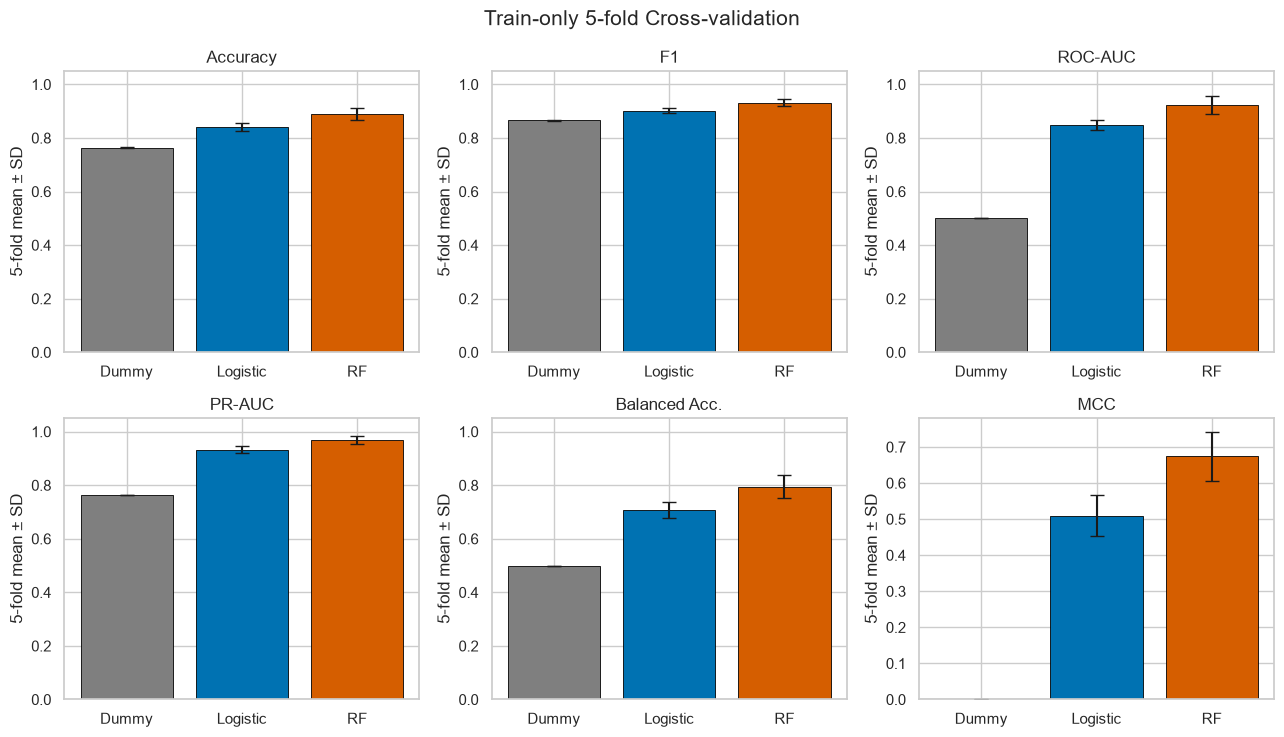

저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day4_cv_comparison.png


In [10]:
plot_metrics = ["accuracy", "f1_score", "roc_auc", "pr_auc", "balanced_accuracy", "mcc"]
plot_labels = {
    "accuracy": "Accuracy",
    "f1_score": "F1",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
    "balanced_accuracy": "Balanced Acc.",
    "mcc": "MCC",
}
model_order = ["DummyClassifier", "Logistic Regression", "Random Forest"]
colors = ["#7F7F7F", "#0072B2", "#D55E00"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), sharey=False)
for axis, metric in zip(axes.ravel(), plot_metrics):
    metric_summary = (
        cv_summary.loc[cv_summary["metric"] == metric]
        .set_index("model")
        .reindex(model_order)
    )
    positions = np.arange(len(model_order))
    axis.bar(
        positions,
        metric_summary["mean"],
        yerr=metric_summary["std"],
        capsize=5,
        color=colors,
        edgecolor="black",
        linewidth=0.6,
    )
    axis.set_xticks(positions, ["Dummy", "Logistic", "RF"])
    axis.set_title(plot_labels[metric])
    axis.set_ylabel("5-fold mean ± SD")
    if metric != "mcc":
        axis.set_ylim(0, 1.05)
    else:
        axis.axhline(0, color="black", linewidth=0.8)

fig.suptitle("Train-only 5-fold Cross-validation", fontsize=15)
fig.tight_layout()
cv_plot_path = RESULTS_DIR / "day4_cv_comparison.png"
fig.savefig(cv_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"저장 위치: {cv_plot_path}")

### 클래스 불균형이 Dummy 점수에 주는 영향

train 데이터의 약 76%가 BBB+입니다. `DummyClassifier(strategy="most_frequent")`는 모든 분자를 다수 클래스인 BBB+로 예측합니다. 그래서 **Accuracy와 BBB+를 양성으로 둔 F1은 겉보기에 높을 수 있지만**, BBB-를 하나도 찾아내지 못해 Specificity, Balanced Accuracy, MCC를 함께 보면 한계를 분명히 확인할 수 있습니다.

## 10. 고정 test set의 확장 지표

**입력:** Day 3 재현 단계에서 이미 얻은 동일한 test 예측과 BBB+ 확률입니다. 새로 학습하거나 임계값을 바꾸지 않습니다.  
**계산:** 기존 Accuracy, F1, ROC-AUC에 Precision, PR-AUC, Balanced Accuracy, MCC, Sensitivity, Specificity를 추가합니다.  
**출력:** 모델별 확장 지표와 confusion matrix 숫자를 CSV로 저장합니다.  
**왜 필요한가:** BBB+가 많은 데이터에서는 Accuracy만으로 BBB- 구분 능력을 충분히 알 수 없기 때문입니다.

- **Precision:** BBB+라고 예측한 것 중 실제 BBB+ 비율
- **Sensitivity:** 실제 BBB+ 중 BBB+로 맞힌 비율
- **Specificity:** 실제 BBB- 중 BBB-로 맞힌 비율
- **Balanced Accuracy:** Sensitivity와 Specificity의 평균
- **MCC:** 네 confusion matrix 칸을 모두 반영한 -1~1 점수
- **PR-AUC:** BBB+ 정밀도와 재현율의 순위 성능을 요약한 값

In [11]:
extended_rows = []
for model_name in base_models:
    artifact = day3_artifacts[model_name]
    prediction = artifact["prediction"]
    probability = artifact["probability"]
    tn, fp, fn, tp = artifact["confusion_matrix"].ravel()
    extended_rows.append(
        {
            "model": model_name,
            "feature_set": feature_names[model_name],
            "threshold": THRESHOLD,
            "accuracy": accuracy_score(y_test, prediction),
            "precision": precision_score(y_test, prediction, pos_label=1, zero_division=0),
            "f1_score": f1_score(y_test, prediction, pos_label=1, zero_division=0),
            "roc_auc": roc_auc_score(y_test, probability),
            "pr_auc": average_precision_score(y_test, probability),
            "balanced_accuracy": balanced_accuracy_score(y_test, prediction),
            "mcc": matthews_corrcoef(y_test, prediction),
            "sensitivity": recall_score(y_test, prediction, pos_label=1, zero_division=0),
            "specificity": recall_score(y_test, prediction, pos_label=0, zero_division=0),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        }
    )

test_metrics_extended = pd.DataFrame(extended_rows)
test_metrics_path = RESULTS_DIR / "day4_test_metrics_extended.csv"
test_metrics_extended.to_csv(
    test_metrics_path, index=False, encoding="utf-8", float_format="%.6f"
)
display(test_metrics_extended.round(4))
print(f"저장 위치: {test_metrics_path}")

,model,feature_set,threshold,accuracy,precision,f1_score,roc_auc,pr_auc,balanced_accuracy,mcc,sensitivity,specificity,tn,fp,fn,tp
0,DummyClassifier,입력을 무시함,0.5,0.7634,0.7634,0.8658,0.5000,0.7634,0.5000,0.0000,1.00,0.0000,0,93,0,300
1,Logistic Regression,8 RDKit descriptors,0.5,0.8550,0.8649,0.9100,0.8475,0.9266,0.7381,0.5626,0.96,0.5161,48,45,12,288
2,Random Forest,"Morgan radius=2, 2048 bits",0.5,0.8830,0.8802,0.9274,0.8960,0.9496,0.7749,0.6543,0.98,0.5699,53,40,6,294


저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day4_test_metrics_extended.csv


## 11. Random Forest의 test 오류 표 만들기

**입력:** Random Forest의 고정 test 예측, BBB+ 확률, 원본 식별 정보와 8개 descriptor입니다.  
**계산:** 각 test 분자를 TN, FP, FN, TP로 나누고 그중 FP와 FN만 오류 표에 모읍니다.  
**출력:** 각 오류 분자의 `num`, 이름, 원본/canonical SMILES, 실제·예측 라벨, 확률, 오류 유형, 8개 descriptor가 담긴 CSV입니다.  
**왜 필요한가:** 전체 점수만으로는 어떤 종류의 실수가 많았는지 알 수 없기 때문입니다.

- **FP:** 실제 BBB-인데 BBB+로 예측
- **FN:** 실제 BBB+인데 BBB-로 예측

In [12]:
rf_artifact = day3_artifacts["Random Forest"]
test_analysis = test_df[["source_index", "num", "name", "smiles", "canonical_smiles"]].copy()
test_analysis["mol"] = test_df["mol"].tolist()
test_analysis["actual_label"] = y_test
test_analysis["predicted_label"] = rf_artifact["prediction"]
test_analysis["bbb_positive_probability"] = rf_artifact["probability"]
test_analysis["error_type"] = np.select(
    [
        (test_analysis["actual_label"] == 0) & (test_analysis["predicted_label"] == 0),
        (test_analysis["actual_label"] == 0) & (test_analysis["predicted_label"] == 1),
        (test_analysis["actual_label"] == 1) & (test_analysis["predicted_label"] == 0),
        (test_analysis["actual_label"] == 1) & (test_analysis["predicted_label"] == 1),
    ],
    ["TN", "FP", "FN", "TP"],
    default="unknown",
)
test_analysis = pd.concat(
    [test_analysis.reset_index(drop=True), X_test_descriptors.reset_index(drop=True)],
    axis=1,
)

error_columns = [
    "source_index", "num", "name", "smiles", "canonical_smiles",
    "actual_label", "predicted_label", "bbb_positive_probability", "error_type",
    *DESCRIPTOR_NAMES,
]
rf_errors = test_analysis.loc[
    test_analysis["error_type"].isin(["FP", "FN"]), error_columns
].copy()
rf_error_path = RESULTS_DIR / "day4_random_forest_test_errors.csv"
rf_errors.to_csv(rf_error_path, index=False, encoding="utf-8", float_format="%.6f")

error_counts = test_analysis["error_type"].value_counts().reindex(["TN", "FP", "FN", "TP"])
assert error_counts.to_dict() == {"TN": 53, "FP": 40, "FN": 6, "TP": 294}
assert len(rf_errors) == 46
display(error_counts.rename("분자 수").to_frame())
display(rf_errors.head())
print(f"저장 위치: {rf_error_path}")

,분자 수
error_type,
TN,53
FP,40
FN,6
TP,294


,source_index,num,name,smiles,canonical_smiles,actual_label,predicted_label,bbb_positive_probability,error_type,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,RingCount,FractionCSP3
8,56,57,compound 36,CN(C)Cc1ccc(CSCCNC2=C([N+]([O-])=O)C(Cc3ccccc3)=CN2)o1,CN(C)Cc1ccc(CSCCNc2[nH]cc(Cc3ccccc3)c2[N+](=O)[O-])o1,1,0,0.403333,FN,414.531,4.5136,87.34,2,6,11,3,0.333333
17,258,260,guanethidinesulfate,NC(N)=NCCN1CCCCCCC1,NC(N)=NCCN1CCCCCCC1,0,1,0.953333,FP,198.314,0.5259,67.64,2,2,3,1,0.900000
32,186,188,Domperidone,Clc1ccc2N(C3CCN(CCCN4C(=O)Nc5ccccc45)CC3)C(=O)Nc2c1,O=c1[nH]c2ccccc2n1CCCN1CCC(n2c(=O)[nH]c3cc(Cl)ccc32)CC1,0,1,0.973333,FP,425.920,3.3532,78.82,2,3,5,5,0.363636
34,691,693,Amifostine,NCCCNCCS[P](O)(O)=O,NCCCNCCSP(=O)(O)O,0,1,0.873333,FP,214.227,-0.2493,95.58,4,4,7,0,1.000000
60,283,285,mannitol,OCC(O)C(O)C(O)C(O)CO,OCC(O)C(O)C(O)C(O)CO,0,1,0.893333,FP,182.172,-3.5854,121.38,6,6,5,0,1.000000


저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day4_random_forest_test_errors.csv


## 12. 확신도가 높은 FP/FN 예시 분자

**입력:** 위 오류 표의 FP와 FN입니다.  
**계산:** FP는 BBB+ 확률이 가장 높은 순서, FN은 BBB+ 확률이 가장 낮은 순서로 각각 최대 6개를 고릅니다. 이는 모델의 확신도가 컸지만 틀린 사례라는 뜻입니다.  
**출력:** 분자 구조와 `이름/num`, 실제 라벨, BBB+ 확률, FP/FN 표시가 있는 이미지입니다.  
**왜 필요한가:** 오류 CSV의 긴 SMILES만 보는 것보다 대표 오류의 구조를 쉽게 확인하기 위해서입니다. 이 그림만으로 오류의 화학적 원인을 단정하지 않습니다.

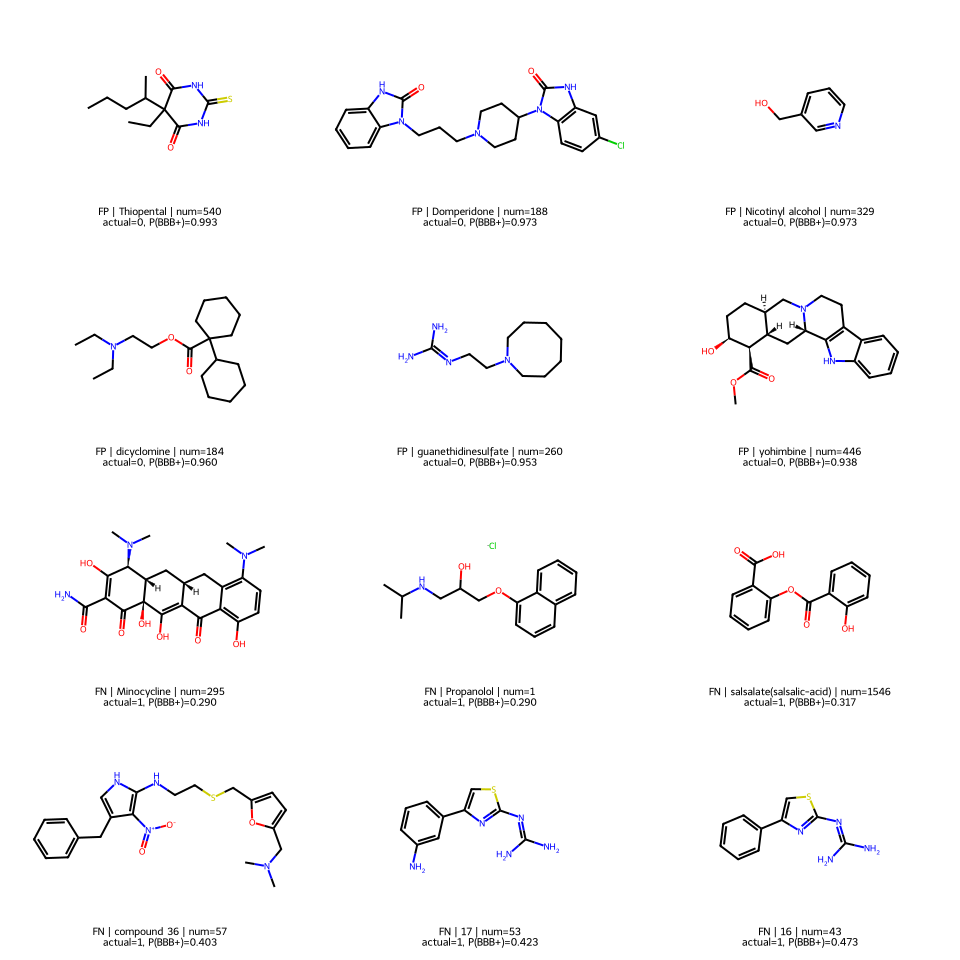

FP 예시 6개, FN 예시 6개
저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day4_high_confidence_errors.png


In [13]:
high_confidence_fp = (
    test_analysis.loc[test_analysis["error_type"] == "FP"]
    .sort_values("bbb_positive_probability", ascending=False)
    .head(6)
)
high_confidence_fn = (
    test_analysis.loc[test_analysis["error_type"] == "FN"]
    .sort_values("bbb_positive_probability", ascending=True)
    .head(6)
)
high_confidence_errors = pd.concat([high_confidence_fp, high_confidence_fn], ignore_index=True)

molecules = high_confidence_errors["mol"].tolist()
legends = []
for _, row in high_confidence_errors.iterrows():
    short_name = str(row["name"]) if pd.notna(row["name"]) else f"num={row['num']}"
    short_name = short_name[:24]
    legends.append(
        f"{row['error_type']} | {short_name} | num={row['num']}\n"
        f"actual={int(row['actual_label'])}, P(BBB+)={row['bbb_positive_probability']:.3f}"
    )

error_grid = Draw.MolsToGridImage(
    molecules,
    molsPerRow=3,
    subImgSize=(320, 240),
    legends=legends,
    useSVG=False,
)
high_confidence_path = RESULTS_DIR / "day4_high_confidence_errors.png"
if hasattr(error_grid, "save"):
    error_grid.save(high_confidence_path)
else:
    high_confidence_path.write_bytes(error_grid.data)
display(error_grid)
print(f"FP 예시 {len(high_confidence_fp)}개, FN 예시 {len(high_confidence_fn)}개")
print(f"저장 위치: {high_confidence_path}")

## 13. TN/FP/FN/TP의 descriptor 비교

**입력:** Random Forest test 분자를 TN, FP, FN, TP로 나눈 표와 8개 descriptor입니다.  
**계산:** 각 그룹에서 descriptor별 평균과 중앙값을 구합니다. 표본 수가 작은 FN은 값이 쉽게 흔들릴 수 있으므로 개수도 함께 저장합니다.  
**출력:** 32행(4개 그룹 × 8개 descriptor)의 요약 CSV입니다.  
**왜 필요한가:** 오류 그룹 사이에서 관찰되는 수치 차이를 정량적으로 기록하기 위해서입니다.

In [14]:
outcome_order = ["TN", "FP", "FN", "TP"]
descriptor_summary_rows = []
for outcome in outcome_order:
    group = test_analysis.loc[test_analysis["error_type"] == outcome]
    for descriptor in DESCRIPTOR_NAMES:
        descriptor_summary_rows.append(
            {
                "outcome": outcome,
                "descriptor": descriptor,
                "count": len(group),
                "mean": group[descriptor].mean(),
                "median": group[descriptor].median(),
            }
        )

error_descriptor_summary = pd.DataFrame(descriptor_summary_rows)
descriptor_summary_path = RESULTS_DIR / "day4_error_descriptor_summary.csv"
error_descriptor_summary.to_csv(
    descriptor_summary_path, index=False, encoding="utf-8", float_format="%.6f"
)
assert error_descriptor_summary.shape == (32, 5)
display(error_descriptor_summary.round(3))
print(f"저장 위치: {descriptor_summary_path}")

,outcome,descriptor,count,mean,median
0,TN,MolWt,53,529.596,477.603
1,TN,MolLogP,53,0.794,0.633
2,TN,TPSA,53,165.238,181.620
3,TN,NumHDonors,53,4.075,4.000
4,TN,NumHAcceptors,53,9.472,10.000
5,TN,NumRotatableBonds,53,6.019,6.000
6,TN,RingCount,53,3.868,4.000
7,TN,FractionCSP3,53,0.494,0.438
8,FP,MolWt,40,312.763,270.800
9,FP,MolLogP,40,1.450,1.603


저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day4_error_descriptor_summary.csv


**입력:** TN/FP/FN/TP가 표시된 test 데이터입니다.  
**계산:** MolWt, MolLogP, TPSA 분포를 boxplot으로 비교합니다. 상자 안의 선은 중앙값이고, 점들은 각 분자를 나타냅니다.  
**출력:** `results/day4_error_descriptor_comparison.png`입니다.  
**왜 필요한가:** 평균만으로 가려질 수 있는 분포의 겹침과 퍼짐을 같이 보기 위해서입니다.

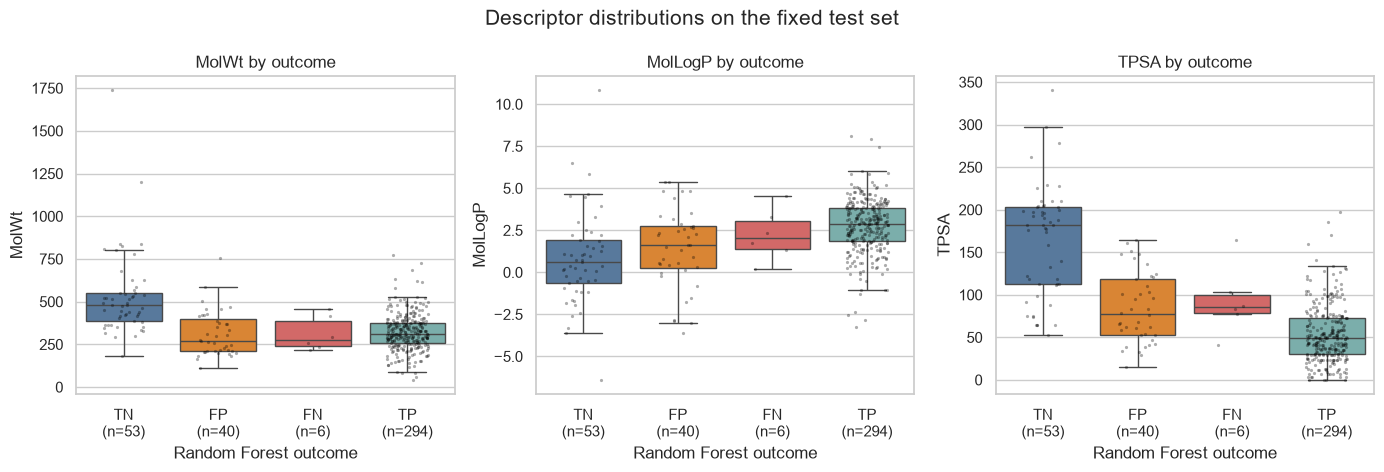

저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day4_error_descriptor_comparison.png


In [15]:
comparison_descriptors = ["MolWt", "MolLogP", "TPSA"]
group_counts = test_analysis["error_type"].value_counts().to_dict()
x_labels = [f"{name}\n(n={group_counts[name]})" for name in outcome_order]
palette = {"TN": "#4C78A8", "FP": "#F58518", "FN": "#E45756", "TP": "#72B7B2"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
for axis, descriptor in zip(axes, comparison_descriptors):
    sns.boxplot(
        data=test_analysis,
        x="error_type",
        y=descriptor,
        order=outcome_order,
        hue="error_type",
        palette=palette,
        legend=False,
        showfliers=False,
        ax=axis,
    )
    sns.stripplot(
        data=test_analysis,
        x="error_type",
        y=descriptor,
        order=outcome_order,
        color="black",
        alpha=0.32,
        size=2.3,
        jitter=0.22,
        ax=axis,
    )
    axis.set_xticks(range(4), x_labels)
    axis.set_xlabel("Random Forest outcome")
    axis.set_ylabel(descriptor)
    axis.set_title(f"{descriptor} by outcome")

fig.suptitle("Descriptor distributions on the fixed test set", fontsize=15)
fig.tight_layout()
descriptor_plot_path = RESULTS_DIR / "day4_error_descriptor_comparison.png"
fig.savefig(descriptor_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"저장 위치: {descriptor_plot_path}")

### 그래프에서 확인한 사실을 수치로 적기

아래 셀은 방금 만든 표의 실제 수치를 Markdown 문장으로 표시합니다. 수치 차이는 **연관된 관찰**일 뿐, BBB 투과나 오류의 원인이라고 해석하지 않습니다.

**입력:** 오류 유형별 개수와 descriptor 중앙값입니다.  
**계산:** FP/FN 수와 MolWt, MolLogP, TPSA 중앙값을 문장으로 정리합니다.  
**출력:** 4개의 관찰 문장입니다.  
**왜 필요한가:** 그래프에서 보이는 사실과 해석을 구분해서 기록하기 위해서입니다.

In [16]:
median_table = (
    error_descriptor_summary
    .pivot(index="outcome", columns="descriptor", values="median")
    .reindex(outcome_order)
)
observation_text = f'''
- 고정 test set에서 Random Forest의 FP는 {group_counts['FP']}개, FN은 {group_counts['FN']}개로 FP가 더 많았습니다.
- MolWt 중앙값은 TN {median_table.loc['TN', 'MolWt']:.1f}, FP {median_table.loc['FP', 'MolWt']:.1f}, FN {median_table.loc['FN', 'MolWt']:.1f}, TP {median_table.loc['TP', 'MolWt']:.1f}이었습니다.
- MolLogP 중앙값은 TN {median_table.loc['TN', 'MolLogP']:.2f}, FP {median_table.loc['FP', 'MolLogP']:.2f}, FN {median_table.loc['FN', 'MolLogP']:.2f}, TP {median_table.loc['TP', 'MolLogP']:.2f}였습니다.
- TPSA 중앙값은 TN {median_table.loc['TN', 'TPSA']:.1f}, FP {median_table.loc['FP', 'TPSA']:.1f}, FN {median_table.loc['FN', 'TPSA']:.1f}, TP {median_table.loc['TP', 'TPSA']:.1f}이었습니다. 네 그룹의 분포는 서로 겹쳤습니다.
'''
display(Markdown(observation_text))


- 고정 test set에서 Random Forest의 FP는 40개, FN은 6개로 FP가 더 많았습니다.
- MolWt 중앙값은 TN 477.6, FP 270.8, FN 276.5, TP 311.9이었습니다.
- MolLogP 중앙값은 TN 0.63, FP 1.60, FN 2.01, TP 2.86였습니다.
- TPSA 중앙값은 TN 181.6, FP 77.8, FN 85.6, TP 49.2이었습니다. 네 그룹의 분포는 서로 겹쳤습니다.


## 14. Day 4 핵심 질문에 답하기

**입력:** train-only 교차검증 요약과 고정 test 확장 지표입니다.  
**계산:** 미리 정한 8개 질문에 실제 숫자로 답합니다. “최고”는 해당 질문에서 명시한 지표를 기준으로만 판단합니다.  
**출력:** 재현 가능한 Day 4 결론입니다.  
**왜 필요한가:** 여러 표의 숫자를 프로젝트 연구 질문과 연결하되, 데이터가 말하지 않는 내용을 과장하지 않기 위해서입니다.

In [17]:
rf_cv = cv_fold_metrics.loc[cv_fold_metrics["model"] == "Random Forest"]
rf_auc_mean = rf_cv["roc_auc"].mean()
rf_auc_std = rf_cv["roc_auc"].std(ddof=1)
rf_auc_min = rf_cv["roc_auc"].min()
rf_auc_max = rf_cv["roc_auc"].max()
rf_test = test_metrics_extended.set_index("model").loc["Random Forest"]
rf_best_auc_folds = sum(
    cv_fold_metrics.loc[cv_fold_metrics["fold"] == fold]
    .sort_values("roc_auc", ascending=False)
    .iloc[0]["model"] == "Random Forest"
    for fold in range(1, 6)
)
best_specificity_model = test_metrics_extended.sort_values(
    "specificity", ascending=False
).iloc[0]["model"]
auc_position = (
    "fold 최솟값과 최댓값 사이에 있습니다"
    if rf_auc_min <= rf_test["roc_auc"] <= rf_auc_max
    else "fold 최솟값과 최댓값 범위를 벗어납니다"
)
class_strength = "BBB+" if rf_test["sensitivity"] > rf_test["specificity"] else "BBB-"

answer_text = f'''
1. **Random Forest가 모든 fold에서 최고였나?** ROC-AUC 기준 {rf_best_auc_folds}/5개 fold에서 가장 높았습니다. 따라서 {'모든 fold에서 가장 높았습니다' if rf_best_auc_folds == 5 else '모든 fold에서 가장 높았던 것은 아닙니다'}.
2. **Random Forest fold ROC-AUC 변동은?** 평균 {rf_auc_mean:.4f}, 표준편차 {rf_auc_std:.4f}, 범위 {rf_auc_min:.4f}~{rf_auc_max:.4f}였습니다.
3. **test ROC-AUC 0.8960은 CV와 비슷한가?** 재현 test 값은 {rf_test['roc_auc']:.4f}이고, CV 평균은 {rf_auc_mean:.4f}입니다. test 값은 {auc_position}. 단, test와 CV fold는 서로 다른 표본입니다.
4. **Accuracy와 Balanced Accuracy의 차이는?** Random Forest test Accuracy는 {rf_test['accuracy']:.4f}, Balanced Accuracy는 {rf_test['balanced_accuracy']:.4f}로 차이는 {abs(rf_test['accuracy'] - rf_test['balanced_accuracy']):.4f}입니다.
5. **고정 test에서 BBB-를 가장 잘 찾은 모델은?** Specificity 기준 `{best_specificity_model}`입니다.
6. **Random Forest 오류는 FP와 FN 중 무엇이 많은가?** FP {group_counts['FP']}개, FN {group_counts['FN']}개로 FP가 더 많았습니다.
7. **Random Forest는 BBB+와 BBB- 중 무엇을 더 잘 찾았나?** Sensitivity={rf_test['sensitivity']:.4f}, Specificity={rf_test['specificity']:.4f}이므로 이 test set에서는 {class_strength}를 더 높은 비율로 맞혔습니다.
8. **무엇을 말할 수 없는가?** 이 결과만으로 descriptor 차이가 BBB 투과 또는 예측 오류의 원인이라고 말할 수 없습니다. 또한 한 번의 random split 결과이므로 새로운 화학 scaffold나 외부 데이터에 같은 성능이 난다고 보장할 수 없습니다.
'''
display(Markdown(answer_text))


1. **Random Forest가 모든 fold에서 최고였나?** ROC-AUC 기준 5/5개 fold에서 가장 높았습니다. 따라서 모든 fold에서 가장 높았습니다.
2. **Random Forest fold ROC-AUC 변동은?** 평균 0.9237, 표준편차 0.0326, 범위 0.8895~0.9638였습니다.
3. **test ROC-AUC 0.8960은 CV와 비슷한가?** 재현 test 값은 0.8960이고, CV 평균은 0.9237입니다. test 값은 fold 최솟값과 최댓값 사이에 있습니다. 단, test와 CV fold는 서로 다른 표본입니다.
4. **Accuracy와 Balanced Accuracy의 차이는?** Random Forest test Accuracy는 0.8830, Balanced Accuracy는 0.7749로 차이는 0.1080입니다.
5. **고정 test에서 BBB-를 가장 잘 찾은 모델은?** Specificity 기준 `Random Forest`입니다.
6. **Random Forest 오류는 FP와 FN 중 무엇이 많은가?** FP 40개, FN 6개로 FP가 더 많았습니다.
7. **Random Forest는 BBB+와 BBB- 중 무엇을 더 잘 찾았나?** Sensitivity=0.9800, Specificity=0.5699이므로 이 test set에서는 BBB+를 더 높은 비율로 맞혔습니다.
8. **무엇을 말할 수 없는가?** 이 결과만으로 descriptor 차이가 BBB 투과 또는 예측 오류의 원인이라고 말할 수 없습니다. 또한 한 번의 random split 결과이므로 새로운 화학 scaffold나 외부 데이터에 같은 성능이 난다고 보장할 수 없습니다.


## 15. 최종 자동 검증

**입력:** 오늘 생성한 표·그림·검증 변수와 Day 3 기준 파일입니다.  
**계산:** 필수 파일 존재, test의 CV 제외, 같은 fold 사용, fold별 scaler 학습, 모델 설정, 임계값, CSV 숫자 일치를 다시 확인합니다.  
**출력:** 모든 검사가 통과했다는 요약표입니다.  
**왜 필요한가:** 노트북이 끝까지 실행됐다는 사실뿐 아니라 분석 규칙이 실제로 지켜졌는지 확인하기 위해서입니다.

In [18]:
required_day4_outputs = [
    cv_fold_path,
    cv_summary_path,
    cv_plot_path,
    test_metrics_path,
    rf_error_path,
    high_confidence_path,
    descriptor_summary_path,
    descriptor_plot_path,
]

assert all(path.exists() and path.stat().st_size > 0 for path in required_day4_outputs)
assert all(signatures == fold_reference_signatures for signatures in validation_signatures_by_model.values())
assert len(scaler_fold_checks) == 5 and all(scaler_fold_checks)
assert set(train_df["source_index"]).isdisjoint(set(test_df["source_index"]))
assert THRESHOLD == 0.5
assert base_models["Random Forest"].n_estimators == 300
assert base_models["Logistic Regression"].named_steps["classifier"].max_iter == 1000
assert len(pd.read_csv(cv_fold_path)) == len(cv_fold_metrics)
assert len(pd.read_csv(cv_summary_path)) == len(cv_summary)
assert len(pd.read_csv(test_metrics_path)) == len(test_metrics_extended)
assert len(pd.read_csv(rf_error_path)) == len(rf_errors)
assert len(pd.read_csv(descriptor_summary_path)) == len(error_descriptor_summary)
assert not (PROJECT_ROOT / "BBBP.csv").exists()

final_check = pd.DataFrame(
    {
        "검증 항목": [
            "Day 3 분할/지표 재현",
            "CV에서 test 제외",
            "세 모델이 같은 fold 사용",
            "Logistic scaler fold-train 전용",
            "결정 기준 0.5 유지",
            "Day 4 필수 결과 파일",
        ],
        "결과": ["통과", "통과", "통과", "통과", "통과", f"{len(required_day4_outputs)}개 확인"],
    }
)
display(final_check)
print("Day 4 완료: 새 모델, 튜닝, threshold 변경 없이 검증과 오류 분석만 수행했습니다.")

,검증 항목,결과
0,Day 3 분할/지표 재현,통과
1,CV에서 test 제외,통과
2,세 모델이 같은 fold 사용,통과
3,Logistic scaler fold-train 전용,통과
4,결정 기준 0.5 유지,통과
5,Day 4 필수 결과 파일,8개 확인


Day 4 완료: 새 모델, 튜닝, threshold 변경 없이 검증과 오류 분석만 수행했습니다.
